## In this notebook i am using for only data understanding by using pyspark 


1. SPARK SETUP


In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("nyc-taxi-trip-duration-prediction") \
    .master("local[*]") \
    .getOrCreate()


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/20 09:03:16 WARN Utils: Your hostname, Mounis-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 192.168.0.16 instead (on interface en0)
26/03/20 09:03:16 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/20 09:03:17 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/20 09:03:17 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/03/20 09:03:17 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


2. Dataset loading 

In [2]:
# loading the data
taxi_df=spark.read.csv("../data/raw/train.csv",header=True, inferSchema=True)


3. Schema Inspection 

In [3]:
# checking the schema of the data(columns and their data types)
taxi_df.printSchema()

root
 |-- id: string (nullable = true)
 |-- vendor_id: integer (nullable = true)
 |-- pickup_datetime: timestamp (nullable = true)
 |-- dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: integer (nullable = true)
 |-- pickup_longitude: double (nullable = true)
 |-- pickup_latitude: double (nullable = true)
 |-- dropoff_longitude: double (nullable = true)
 |-- dropoff_latitude: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- trip_duration: integer (nullable = true)



In [4]:
# printing the first 5 rows of the data
taxi_df.show(5)

+---------+---------+-------------------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+
|       id|vendor_id|    pickup_datetime|   dropoff_datetime|passenger_count|  pickup_longitude|   pickup_latitude| dropoff_longitude|  dropoff_latitude|store_and_fwd_flag|trip_duration|
+---------+---------+-------------------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+
|id2875421|        2|2016-03-14 17:24:55|2016-03-14 17:32:30|              1| -73.9821548461914| 40.76793670654297|-73.96463012695312|40.765602111816406|                 N|          455|
|id2377394|        1|2016-06-12 00:43:35|2016-06-12 00:54:38|              1|-73.98041534423828|40.738563537597656|-73.99948120117188| 40.73115158081055|                 N|          663|
|id3858529|        2|2016-01-19 11:35:24|2016-01-19 12:10:48|    

4. Data Size overview

In [5]:
# knowing the numbers of rows and the columns in the dataset
print(f"number of rows:{taxi_df.count()}")
print(f"number of columns:{len(taxi_df.columns)}")

number of rows:1458644
number of columns:11


In [6]:
# column names in the dataset
taxi_df.columns

['id',
 'vendor_id',
 'pickup_datetime',
 'dropoff_datetime',
 'passenger_count',
 'pickup_longitude',
 'pickup_latitude',
 'dropoff_longitude',
 'dropoff_latitude',
 'store_and_fwd_flag',
 'trip_duration']

In [7]:
# data types of the columns in the dataset
taxi_df.dtypes

[('id', 'string'),
 ('vendor_id', 'int'),
 ('pickup_datetime', 'timestamp'),
 ('dropoff_datetime', 'timestamp'),
 ('passenger_count', 'int'),
 ('pickup_longitude', 'double'),
 ('pickup_latitude', 'double'),
 ('dropoff_longitude', 'double'),
 ('dropoff_latitude', 'double'),
 ('store_and_fwd_flag', 'string'),
 ('trip_duration', 'int')]

5. Summary Statistics 

In [8]:
# fidning the summary statistics of the data
taxi_df.describe().show()

26/03/20 09:03:22 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+---------+-------------------+------------------+-------------------+--------------------+-------------------+-------------------+------------------+------------------+
|summary|       id|          vendor_id|   passenger_count|   pickup_longitude|     pickup_latitude|  dropoff_longitude|   dropoff_latitude|store_and_fwd_flag|     trip_duration|
+-------+---------+-------------------+------------------+-------------------+--------------------+-------------------+-------------------+------------------+------------------+
|  count|  1458644|            1458644|           1458644|            1458644|             1458644|            1458644|            1458644|           1458644|           1458644|
|   mean|     NULL| 1.5349502688798637|1.6645295219395548| -73.97348630489282|  40.750920908391734|  -73.9734159469458|   40.7517995149002|              NULL| 959.4922729603659|
| stddev|     NULL|0.49877715390740074| 1.314242167823115|0.07090185842270368|0.032881186257633095|0.070643268

6. Missing values analysis

In [9]:
# checking for null values in the data
from pyspark.sql.functions import col, count,when
taxi_df.select([count(when(col(c).isNull(),c)).alias(c) for c in taxi_df.columns]).show()

+---+---------+---------------+----------------+---------------+----------------+---------------+-----------------+----------------+------------------+-------------+
| id|vendor_id|pickup_datetime|dropoff_datetime|passenger_count|pickup_longitude|pickup_latitude|dropoff_longitude|dropoff_latitude|store_and_fwd_flag|trip_duration|
+---+---------+---------------+----------------+---------------+----------------+---------------+-----------------+----------------+------------------+-------------+
|  0|        0|              0|               0|              0|               0|              0|                0|               0|                 0|            0|
+---+---------+---------------+----------------+---------------+----------------+---------------+-----------------+----------------+------------------+-------------+



7. Duplicate Analysis
 

In [10]:
# chcking for duplicate values in the data
duplicate_rows=taxi_df.groupBy(taxi_df.columns).count().filter("count > 1")
print(f"number of duplicate rows:{duplicate_rows.count()}")

number of duplicate rows:0


8. Column Distribution 

In [11]:
taxi_df.groupBy("passenger_count").count().show()

+---------------+-------+
|passenger_count|  count|
+---------------+-------+
|              1|1033540|
|              6|  48333|
|              3|  59896|
|              5|  78088|
|              4|  28404|
|              2| 210318|
|              0|     60|
|              9|      1|
|              7|      3|
|              8|      1|
+---------------+-------+



9. Distribution of the target variable

In [12]:
taxi_df.select("trip_duration").describe().show()

+-------+------------------+
|summary|     trip_duration|
+-------+------------------+
|  count|           1458644|
|   mean| 959.4922729603659|
| stddev|5237.4317244975955|
|    min|                 1|
|    max|           3526282|
+-------+------------------+



In [13]:
taxi_df.orderBy("trip_duration", ascending=True).show(10)

+---------+---------+-------------------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+
|       id|vendor_id|    pickup_datetime|   dropoff_datetime|passenger_count|  pickup_longitude|   pickup_latitude| dropoff_longitude|  dropoff_latitude|store_and_fwd_flag|trip_duration|
+---------+---------+-------------------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+
|id2608913|        1|2016-03-12 02:15:31|2016-03-12 02:15:32|              1|-73.94940185546875| 40.79683303833008| -73.9494857788086| 40.79672622680664|                 N|            1|
|id1520236|        1|2016-05-17 09:03:38|2016-05-17 09:03:39|              1|-73.81989288330078|40.740821838378906|-73.81988525390625|40.740821838378906|                 N|            1|
|id2402793|        1|2016-04-30 00:28:45|2016-04-30 00:28:46|    

In [14]:
!pip install seaborn

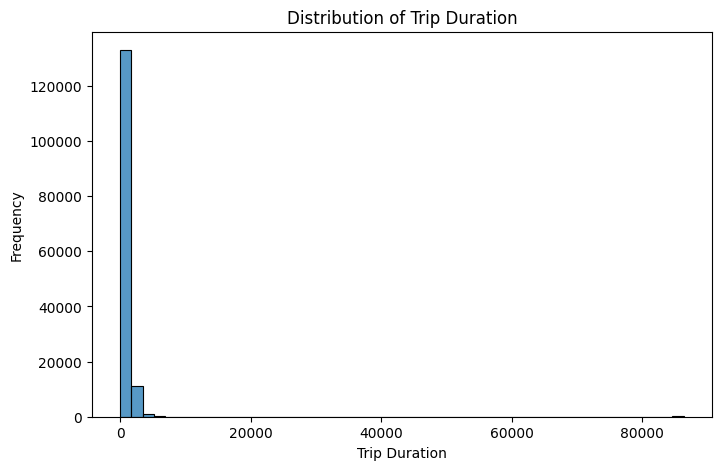

26/03/20 19:23:26 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 1223928 ms exceeds timeout 120000 ms
26/03/20 19:23:26 WARN SparkContext: Killing executors is not supported by current scheduler.
26/03/20 19:23:27 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:81)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:674)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1363)
	at 

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sample_df = taxi_df.select("trip_duration").sample(False, 0.1, seed=42).toPandas()

plt.figure(figsize=(8,5))
sns.histplot(sample_df["trip_duration"], bins=50)

plt.title("Distribution of Trip Duration")
plt.xlabel("Trip Duration")
plt.ylabel("Frequency")

plt.savefig("../reports/figures/trip_duration_distribution.png")
plt.show()